# Explore here

In [10]:
#dividir la carpeta de train en nuna carpeta de dogs y otra carpeta de cats
import os
import shutil

def split_train_folder(train_folder):
    dogs_folder = os.path.join(train_folder, 'dogs')
    cats_folder = os.path.join(train_folder, 'cats')

    # Crear las carpetas de dogs y cats si no existen
    os.makedirs(dogs_folder, exist_ok=True)
    os.makedirs(cats_folder, exist_ok=True)

    # Iterar sobre los archivos en la carpeta de train
    for filename in os.listdir(train_folder):
        #evita la carpeta dogs y cats
        if filename in ['dogs', 'cats']:
            continue
        if filename.startswith('dog'):
            shutil.move(os.path.join(train_folder, filename), os.path.join(dogs_folder, filename))
        elif filename.startswith('cat'):
            shutil.move(os.path.join(train_folder, filename), os.path.join(cats_folder, filename))

#ejemplo de uso
train_folder = r"C:\Users\anton\nn\nncatsdogs\data\raw\dogs-vs-cats\train"
split_train_folder(train_folder)


In [11]:
#genera una carpeta de test seleccionando 1250 imagenes de cada clase de la carpeta de train y moviendolas a la carpeta de test
import random

def create_test_folder(train_folder, test_folder, num_samples=1250):
    dogs_folder = os.path.join(train_folder, 'dogs')
    cats_folder = os.path.join(train_folder, 'cats')

    test_dogs_folder = os.path.join(test_folder, 'dogs')
    test_cats_folder = os.path.join(test_folder, 'cats')
    os.makedirs(test_dogs_folder, exist_ok=True)
    os.makedirs(test_cats_folder, exist_ok=True)
    
    dog_files = [f for f in os.listdir(dogs_folder) if f.endswith('.jpg')]
    cat_files = [f for f in os.listdir(cats_folder) if f.endswith('.jpg')]

    selected_dogs = random.sample(dog_files, min(num_samples, len(dog_files)))
    selected_cats = random.sample(cat_files, min(num_samples, len(cat_files)))



    for filename in selected_dogs:
        shutil.copy(os.path.join(dogs_folder, filename), os.path.join(test_dogs_folder, filename))
    for filename in selected_cats:
        shutil.copy(os.path.join(cats_folder, filename), os.path.join(test_cats_folder, filename))
#ejemplo de uso
test_folder = r"C:\Users\anton\nn\nncatsdogs\data\raw\dogs-vs-cats\test"
create_test_folder(train_folder, test_folder)

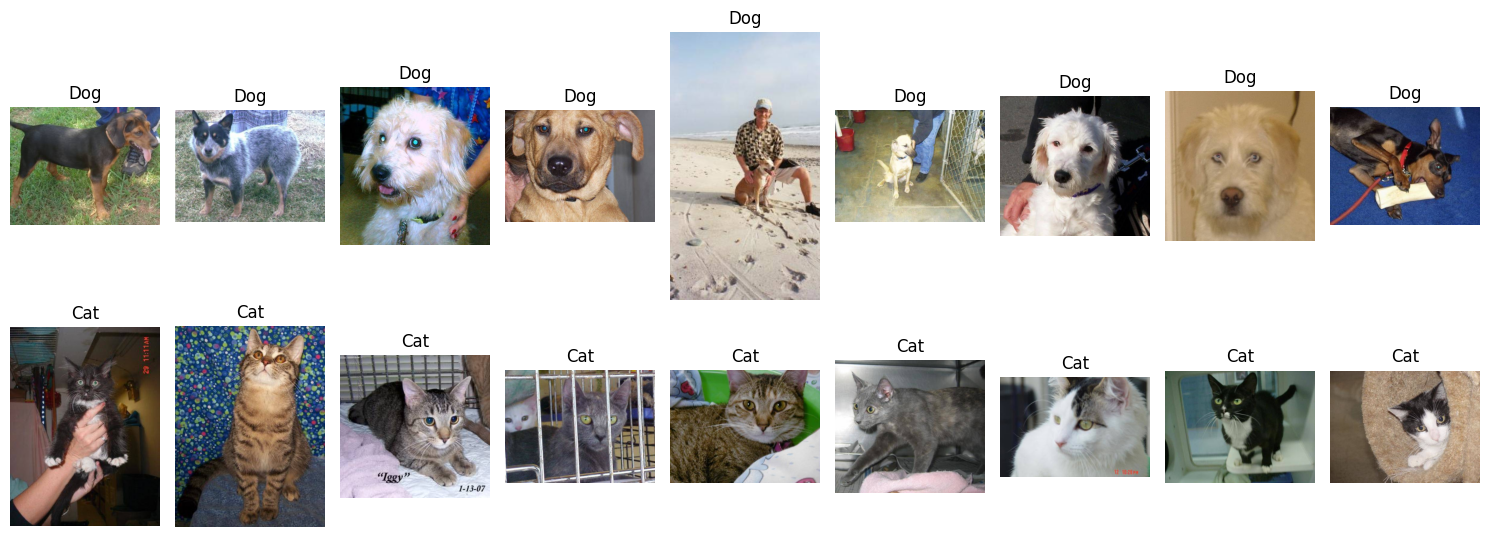

In [13]:
#visualiza 9 fotos de cada clase de la carpeta de test
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg
import random
import os

test_folder = r"C:\Users\anton\nn\nncatsdogs\data\raw\dogs-vs-cats\test"

def visualize_test_samples(test_folder, num_samples=9):
    dog_files = []
    cat_files = []

    for root, dirs, files in os.walk(test_folder):
        for filename in files:
            if filename.lower().endswith('.jpg'):
                if filename.startswith('dog'):
                    dog_files.append(os.path.join(root, filename))
                elif filename.startswith('cat'):
                    cat_files.append(os.path.join(root, filename))

    if len(dog_files) == 0 or len(cat_files) == 0:
        raise ValueError(
            f"No se encontraron imágenes de perro o gato en {test_folder}. "
            "Asegúrate de que las carpetas o los archivos estén en la ruta correcta."
        )

    num_dogs = min(num_samples, len(dog_files))
    num_cats = min(num_samples, len(cat_files))
    if num_dogs < num_samples or num_cats < num_samples:
        print(f"Solo hay {len(dog_files)} perros y {len(cat_files)} gatos disponibles. "
              f"Mostrando {num_dogs} perros y {num_cats} gatos.")

    selected_dogs = random.sample(dog_files, num_dogs)
    selected_cats = random.sample(cat_files, num_cats)

    plt.figure(figsize=(15, 6))

    for i, filepath in enumerate(selected_dogs):
        img = plt.imread(filepath)
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(img)
        plt.title('Dog')
        plt.axis('off')

    for i, filepath in enumerate(selected_cats):
        img = plt.imread(filepath)
        plt.subplot(2, num_samples, num_samples + i + 1)
        plt.imshow(img)
        plt.title('Cat')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_test_samples(test_folder)

In [14]:
#cargar los datos usando imagenDataGenerator de keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def load_data(train_folder, test_folder, img_size=(200, 200), batch_size=32):
  
  #crea una imagenDataGenerator para el entrenamiento con aumento de datos
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    #crea una imagenDataGenerator para el test sin aumento de datos
    test_datagen = ImageDataGenerator(rescale=1./255)

    #carga los datos de entrenamiento y test usando flow_from_directory
    train_generator = train_datagen.flow_from_directory(    
        train_folder,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary'
    )
    test_generator = test_datagen.flow_from_directory(
        test_folder,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary'
    )
    return train_generator, test_generator
#ejemplo de uso
train_generator, test_generator = load_data(train_folder, test_folder)

Found 2500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


In [15]:
#reorganizar archivos en test para que tengan subfolders
import os
import shutil

test_folder = r"C:\Users\anton\nn\nncatsdogs\data\raw\dogs-vs-cats\test"

test_dogs_folder = os.path.join(test_folder, 'dogs')
test_cats_folder = os.path.join(test_folder, 'cats')
os.makedirs(test_dogs_folder, exist_ok=True)
os.makedirs(test_cats_folder, exist_ok=True)

for filename in os.listdir(test_folder):
    if filename.startswith('dog') and filename.endswith('.jpg'):
        shutil.move(os.path.join(test_folder, filename), os.path.join(test_dogs_folder, filename))
    elif filename.startswith('cat') and filename.endswith('.jpg'):
        shutil.move(os.path.join(test_folder, filename), os.path.join(test_cats_folder, filename))

In [16]:
#copiar archivos de test de vuelta a train para tener datos de entrenamiento
import os
import shutil

train_folder = r"C:\Users\anton\nn\nncatsdogs\data\raw\dogs-vs-cats\train"
test_folder = r"C:\Users\anton\nn\nncatsdogs\data\raw\dogs-vs-cats\test"

train_dogs_folder = os.path.join(train_folder, 'dogs')
train_cats_folder = os.path.join(train_folder, 'cats')
test_dogs_folder = os.path.join(test_folder, 'dogs')
test_cats_folder = os.path.join(test_folder, 'cats')

os.makedirs(train_dogs_folder, exist_ok=True)
os.makedirs(train_cats_folder, exist_ok=True)

for filename in os.listdir(test_dogs_folder):
    if not os.path.exists(os.path.join(train_dogs_folder, filename)):
        shutil.copy(os.path.join(test_dogs_folder, filename), os.path.join(train_dogs_folder, filename))

for filename in os.listdir(test_cats_folder):
    if not os.path.exists(os.path.join(train_cats_folder, filename)):
        shutil.copy(os.path.join(test_cats_folder, filename), os.path.join(train_cats_folder, filename))

In [17]:
#hacer modelos de cnn con keras usando vgg16 como base
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models 

#carga el modeloo del vgg16 preentrenado sin partes superiores
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3))    

#crea modelo secuencial y agrega el modelo base
model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

#congela las capas del modelo base para no entrenarlas 
base_model.trainable = False
#complila el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#resumen del modelo
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,433,793 (74.13 MB)

 Trainable params: 4,719,105 (18.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [20]:
#haz prediciciones con el modelo para entrenarlo con gpu

import tensorflow as tf

#chequea si hay una GPU disponible
if tf.config.list_physical_devices('GPU'):
    print("GPU disponible. Usando GPU para entrenamiento.")
else:
    print("No se encontró GPU. Usando CPU para entrenamiento.")

#entrena el modelo
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=1,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size
)

#evaluar el modelo
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test accuracy: {test_acc:.4f}")


No se encontró GPU. Usando CPU para entrenamiento.
78/78 ━━━━━━━━━━━━━━━━━━━━ 1283s 17s/step - accuracy: 0.8128 - loss: 0.4012 - val_accuracy: 0.8886 - val_loss: 0.2612
78/78 ━━━━━━━━━━━━━━━━━━━━ 490s 6s/step - accuracy: 0.8886 - loss: 0.2611
Test accuracy: 0.8886


In [24]:
#guarda el modelo entrenado
model.save('../models/cats_dogs_vgg16.keras')

In [25]:
#rescata el modelo y evalua el test accuaracy
from tensorflow.keras.models import load_model
#carga el modelo guardado
loaded_model = load_model('../models/cats_dogs_vgg16.keras')
#evaluar el modelo cargado con el conjunto de test
test_loss, test_acc = loaded_model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test accuracy del modelo cargado: {test_acc:.4f}")


78/78 ━━━━━━━━━━━━━━━━━━━━ 475s 6s/step - accuracy: 0.8886 - loss: 0.2615
Test accuracy del modelo cargado: 0.8886


Usando imagen: C:\Users\anton\nn\nncatsdogs\data\raw\dogs-vs-cats\test\dogs\dog.0.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
Predicción: Perro


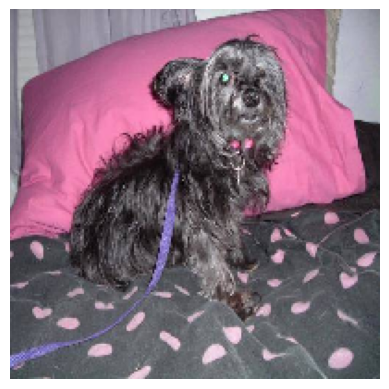

In [27]:
#rescata una imagen de test y haz una prediccion
import numpy as np
from tensorflow.keras.preprocessing import image
from pathlib import Path

# Busca una imagen de prueba válida en el directorio de test
test_image_dir = Path(r"C:\Users\anton\nn\nncatsdogs\data\raw\dogs-vs-cats\test\dogs")
test_images = sorted(test_image_dir.glob('dog*.jpg'))
if not test_images:
    raise FileNotFoundError(f"No se encontraron imágenes en {test_image_dir}")

# Usa la primera imagen disponible
tes_imagen_path = test_images[0]
print('Usando imagen:', tes_imagen_path)

img = image.load_img(tes_imagen_path, target_size=(200, 200))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
# Normaliza y agrega dimensión de batch
img_array /= 255.0
# Realiza la predicción
prediction = loaded_model.predict(img_array)
if prediction[0][0] > 0.5:
    print("Predicción: Perro")
else:
    print("Predicción: Gato")
#muestra la imagen
plt.imshow(img)
plt.axis('off')
plt.show()
